In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
from sympy import *

from ji_tiling import basis2D

In [2]:
import matplotlib.pyplot as plt

In [3]:
A = Matrix( [[0,0,0,0,1],[1,0,0,0,0],[0,1,0,0,0],[0,0,1,0,0],[0,0,0,1,0]] ) # Senechal
# A = Matrix( [[0,0,0,0,1],[1,0,0,0,0],[0,1,0,0,0],[0,0,1,0,0],[0,0,0,1,0]] )
# A = Matrix( [[0,0,1,0,0],[0,0,0,1,0],[0,0,0,0,1],[1,0,0,0,0],[0,1,0,0,0]] )
# A = Matrix( [[0,1,0,0,0],[0,0,1,0,0],[0,0,0,1,0],[0,0,0,0,1],[1,0,0,0,0]] )

In [4]:
A

Matrix([
[0, 0, 0, 0, 1],
[1, 0, 0, 0, 0],
[0, 1, 0, 0, 0],
[0, 0, 1, 0, 0],
[0, 0, 0, 1, 0]])

In [5]:
A.eigenvals()

{1: 1,
 -sqrt(5)/4 - 1/4 - I*sqrt(5/8 - sqrt(5)/8): 1,
 -sqrt(5)/4 - 1/4 + I*sqrt(5/8 - sqrt(5)/8): 1,
 -1/4 + sqrt(5)/4 - I*sqrt(sqrt(5)/8 + 5/8): 1,
 -1/4 + sqrt(5)/4 + I*sqrt(sqrt(5)/8 + 5/8): 1}

In [6]:
v = A.eigenvects()

In [7]:
v[0][0], v[1][0], v[2][0], v[3][0], v[4][0]

(1,
 -1/4 + sqrt(5)/4 - I*sqrt(sqrt(5)/8 + 5/8),
 -1/4 + sqrt(5)/4 + I*sqrt(sqrt(5)/8 + 5/8),
 -sqrt(5)/4 - 1/4 - I*sqrt(5/8 - sqrt(5)/8),
 -sqrt(5)/4 - 1/4 + I*sqrt(5/8 - sqrt(5)/8))

In [8]:
simplify( v[1][-1][0]+v[2][-1][0])

Matrix([
[-1/2 + sqrt(5)/2],
[-sqrt(5)/2 - 1/2],
[-sqrt(5)/2 - 1/2],
[-1/2 + sqrt(5)/2],
[               2]])

In [9]:
simplify( I*(v[2][-1][0]-v[1][-1][0]))

Matrix([
[                   sqrt(2*sqrt(5) + 10)/2],
[(-sqrt(2) + sqrt(10))*sqrt(sqrt(5) + 5)/4],
[(-sqrt(10) + sqrt(2))*sqrt(sqrt(5) + 5)/4],
[                  -sqrt(2*sqrt(5) + 10)/2],
[                                        0]])

In [10]:
simplify( v[3][-1][0]+v[4][-1][0])

Matrix([
[-sqrt(5)/2 - 1/2],
[-1/2 + sqrt(5)/2],
[-1/2 + sqrt(5)/2],
[-sqrt(5)/2 - 1/2],
[               2]])

In [11]:
simplify( I*(v[4][-1][0]-v[3][-1][0]) )

Matrix([
[                   sqrt(10 - 2*sqrt(5))/2],
[sqrt(5 - sqrt(5))*(-sqrt(10) - sqrt(2))/4],
[ sqrt(5 - sqrt(5))*(sqrt(2) + sqrt(10))/4],
[                  -sqrt(10 - 2*sqrt(5))/2],
[                                        0]])

In [12]:
# Senechal's v_1 + v_4 (p. 62)

In [13]:
( v[2][-1][0]+v[1][-1][0] ).n(chop=True) 

Matrix([
[0.618033988749895],
[-1.61803398874989],
[-1.61803398874989],
[0.618033988749895],
[              2.0]])

In [14]:
(I*( v[2][-1][0]-v[1][-1][0] )).n(chop=True)

Matrix([
[ 1.90211303259031],
[ 1.17557050458495],
[-1.17557050458495],
[-1.90211303259031],
[                0]])

## Projection plane

In [15]:
2*np.array( [1,np.cos((2*np.pi)/5),np.cos((4*np.pi)/5),np.cos((6*np.pi)/5),np.cos((8*np.pi)/5)])

array([ 2.        ,  0.61803399, -1.61803399, -1.61803399,  0.61803399])

In [16]:
2*np.array( [0,np.sin((2*np.pi)/5),np.sin((4*np.pi)/5),np.sin((6*np.pi)/5),np.sin((8*np.pi)/5)])

array([ 0.        ,  1.90211303,  1.1755705 , -1.1755705 , -1.90211303])

## Cut window

In [17]:
2*np.array( [1,np.cos((4*np.pi)/5),np.cos((8*np.pi)/5),np.cos((2*np.pi)/5),np.cos((6*np.pi)/5)])

array([ 2.        , -1.61803399,  0.61803399,  0.61803399, -1.61803399])

In [18]:
2*np.array( [0,np.sin((4*np.pi)/5),np.sin((8*np.pi)/5),np.sin((2*np.pi)/5),np.sin((6*np.pi)/5)])

array([ 0.        ,  1.1755705 , -1.90211303,  1.90211303, -1.1755705 ])

In [19]:
np.array((v[2][-1][0]+v[1][-1][0]).n(chop=True)).T

array([[0.618033988749895, -1.61803398874989, -1.61803398874989,
        0.618033988749895, 2.00000000000000]], dtype=object)

In [20]:
i, j = 2, 1

u1 = np.array((v[i][-1][0]+v[j][-1][0]).n(chop=True), dtype=np.float64).T
print(u1)
u2 = np.array(I*(v[i][-1][0]-v[j][-1][0]).n(chop=True), dtype=np.float64).T
print(u2)
# u1 = u1[:,np.array([4,0,1,2,3])] #/ 
print(u1)
# u2 =  u2[:,np.array([4,0,1,2,3])] #/ np.linalg.norm(u2)
print(u2)
u1 /= np.linalg.norm(u1)
print(u1)
u2 /= np.linalg.norm(u2)
print(u2)

[[ 0.61803399 -1.61803399 -1.61803399  0.61803399  2.        ]]
[[ 1.90211303  1.1755705  -1.1755705  -1.90211303  0.        ]]
[[ 0.61803399 -1.61803399 -1.61803399  0.61803399  2.        ]]
[[ 1.90211303  1.1755705  -1.1755705  -1.90211303  0.        ]]
[[ 0.19543951 -0.51166727 -0.51166727  0.19543951  0.63245553]]
[[ 0.60150096  0.37174803 -0.37174803 -0.60150096  0.        ]]


In [21]:
pi_unicode = "\u03C0"

p = np.vstack((u1, u2))

e1 = p@np.array([0,1,0,0,0])
e2 = p@np.array([0,0,1,0,0])
e1 = e1/np.linalg.norm(e1)
e2 = e2/np.linalg.norm(e2)

p_rotation = np.arccos(np.dot(e1,e2))*(5/np.pi)
print(f'-->5D basis vectors are rotated in 2D plane by ({p_rotation}{pi_unicode})/5')

-->5D basis vectors are rotated in 2D plane by (1.9999999999999998π)/5


In [22]:
lo,hi = -1, 2
v_ = np.array(list(range(lo,hi)))
z5 = np.zeros( ((v_.shape[0])**5, 5) )

i=0
for i5 in range(lo,hi):
    for i4 in range(lo,hi):
        for i3 in range(lo,hi):
            for i2 in range(lo,hi):
                for i1 in range(lo,hi):
                    z5[i,:] = np.array([i1,i2,i3,i4,i5])
                    i += 1

In [23]:
pS = symbols('pS')

xy_ = []
r_ = []

rI = np.array([3,5,7,9,11])

for pt5 in z5:    

    # if (np.count_nonzero(pt5) <= 2) and (abs(pt5).max() <= 1):
    if (np.sum(pt5<0) < 2) and (np.sum(pt5>0) < 2):
        print(pt5)
        pS = Rational(rI[0],1)**Integer(pt5[0]) * \
            Rational(rI[1],1)**Integer(pt5[1]) * \
            Rational(rI[2],1)**Integer(pt5[2]) * \
            Rational(rI[3],1)**Integer(pt5[3]) * \
            Rational(rI[4],1)**Integer(pt5[4]) 
    
        while ( pS>2 ):
            pS = pS/ 2
        while ( pS<1 ):
            pS = pS*2
    
        r_.append( str(pS) )
        xy_.append( p@pt5 )

xy_ = np.asarray(xy_)

[ 0.  0.  0.  0. -1.]
[ 1.  0.  0.  0. -1.]
[ 0.  1.  0.  0. -1.]
[ 0.  0.  1.  0. -1.]
[ 0.  0.  0.  1. -1.]
[ 0.  0.  0. -1.  0.]
[ 1.  0.  0. -1.  0.]
[ 0.  1.  0. -1.  0.]
[ 0.  0.  1. -1.  0.]
[ 0.  0. -1.  0.  0.]
[ 1.  0. -1.  0.  0.]
[ 0.  1. -1.  0.  0.]
[ 0. -1.  0.  0.  0.]
[ 1. -1.  0.  0.  0.]
[-1.  0.  0.  0.  0.]
[0. 0. 0. 0. 0.]
[1. 0. 0. 0. 0.]
[-1.  1.  0.  0.  0.]
[0. 1. 0. 0. 0.]
[ 0. -1.  1.  0.  0.]
[-1.  0.  1.  0.  0.]
[0. 0. 1. 0. 0.]
[ 0.  0. -1.  1.  0.]
[ 0. -1.  0.  1.  0.]
[-1.  0.  0.  1.  0.]
[0. 0. 0. 1. 0.]
[ 0.  0.  0. -1.  1.]
[ 0.  0. -1.  0.  1.]
[ 0. -1.  0.  0.  1.]
[-1.  0.  0.  0.  1.]
[0. 0. 0. 0. 1.]


In [24]:
(np.array((np.cos((1*np.pi)/10),-np.sin((1*np.pi)/10)),(np.cos((1*np.pi)/10),np.sin((1*np.pi)/10)))@(xy_.T)).shape

(31,)

In [25]:
xyR = (np.array(((np.cos((1*np.pi)/10),-np.sin((1*np.pi)/10)),(np.sin((1*np.pi)/10),np.cos((1*np.pi)/10))))@(xy_.T)).T

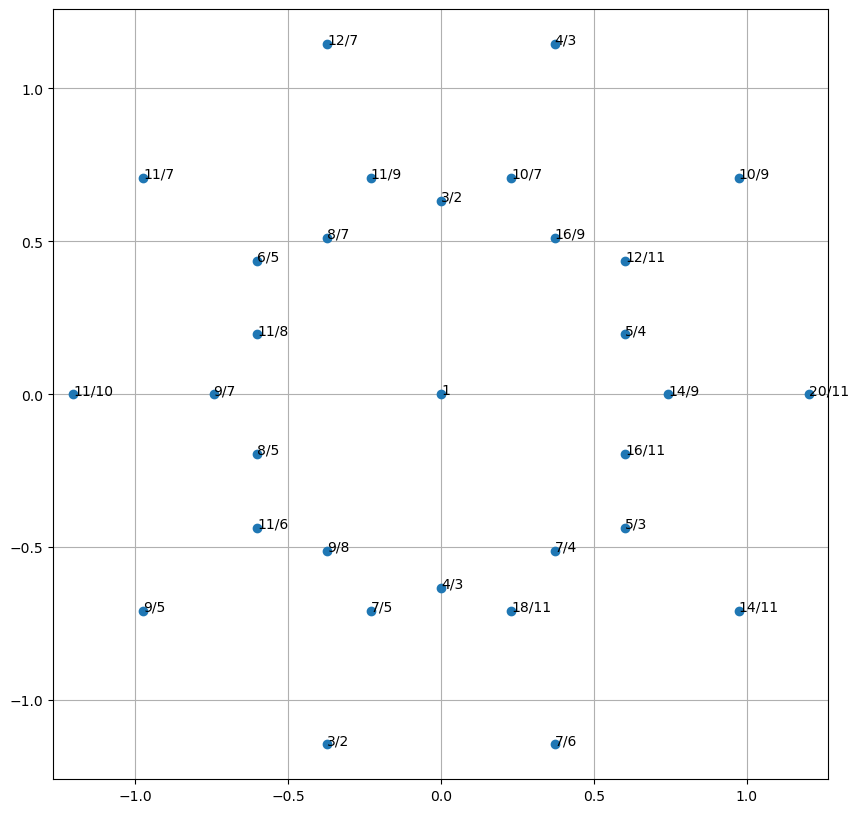

In [26]:
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111)

x_ = -xyR[:,0]
y_ = xyR[:,1]

ax.plot(x_,y_,'o')
for i,rl in enumerate(r_):                                       # <--
    # ax.annotate(rl, xy=xy_[i,:], textcoords='data') # <--
    ax.annotate(rl, xy=[x_[i],y_[i]], textcoords='data') # <--

ax.grid()
plt.axis('equal')
# plt.savefig('hexadic_diamond.png')
plt.show()